<a href="https://colab.research.google.com/github/ssykes-eth/ETH_275-0005-00L/blob/code_exercises/00_cx_training_budget_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Budget the Training Run 💰🖥️

## The situation

You just joined the infra team at a startup racing to train its own language model. Before anyone touches
a GPU, **your manager needs a budget memo**: how many FLOPs will this training run take, how many
GPU-hours does that translate to, what will it cost in dollars, and how much energy will it burn?

Guess wrong and one of two things happens: you under-budget and the run gets killed halfway through, or
you over-budget and the project never gets approved. Your job is to build the estimator that makes sure
neither happens — and to show, visually, how the numbers explode as models get bigger.

You will work through four parts:

| Part | What you do | What you learn |
|---|---|---|
| 1 | Model size + data → total training FLOPs | The `6ND` rule of thumb, and why FLOPs is the currency of scale |
| 2 | FLOPs → GPU-hours | Peak hardware FLOPs vs. what you *actually* get (MFU) |
| 3 | GPU-hours → \$ cost and energy | Cloud pricing, power draw, and carbon cost |
| 4 | Put it together: the budget dashboard | How cost explodes non-linearly with model size, benchmarked against real models |

By the end you will have a working `training_budget(...)` function and a chart you could genuinely put in
front of a manager.


In [1]:
import os, sys

REPO_OWNER = "eth-fdd-fs26"
REPO_NAME  = "FDD-WE7-public"

def _in_colab():
    try:
        import google.colab
        return True
    except Exception:
        return False

if _in_colab():
    url = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
    if not os.path.isdir(REPO_NAME):
        print("Cloning the exercise repo…")
        !git clone -q "$url"
    else:
        print("Updating exercise repo…")
        !cd {REPO_NAME} && git pull -q
    sys.path.insert(0, REPO_NAME)
else:
    print("Running locally — assuming the repo is already on your path.")


Cloning the exercise repo…


In [2]:
#@title Setup: install and import everything (run me) { display-mode: "form" }
%pip install -q ipywidgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import ipywidgets as widgets

# House plot style
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

print("all libraries loaded ✅")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.5 MB/s eta 0:00:00
all libraries loaded ✅


## Part 1: from model size to FLOPs 🎯

To train a dense transformer, a widely used rule of thumb is:

$$\text{Training FLOPs} \approx 6 \cdot N \cdot D$$

where **N** is the number of parameters and **D** is the number of training tokens. The `6` comes from
counting multiply-adds in the forward pass (≈2N FLOPs per token) and the backward pass, which costs
roughly twice the forward pass (≈4N FLOPs per token) — so `2N + 4N = 6N` FLOPs per token, times `D`
tokens.

This single formula is the reason people can put a number on "how big" a training run is before a single
GPU is booked.


In [3]:
def total_train_flops(n_params: float, n_tokens: float) -> float:
    '''Estimate total training FLOPs using the 6ND rule of thumb.

    Args:
        n_params: number of model parameters (N)
        n_tokens: number of training tokens (D)

    Returns:
        Estimated total FLOPs for the full training run.
    '''
    # 🎯 TODO: implement the 6ND rule
    # Hint: it's a one-liner
    total_flops = 6 * n_params * n_tokens
    return total_flops


# Sanity check: a 1B-parameter model trained on 20B tokens (Chinchilla-optimal ratio ~20 tokens/param)
test_flops = total_train_flops(1e9, 20e9)
print(f"1B model on 20B tokens ≈ {test_flops:.2e} FLOPs")

1B model on 20B tokens ≈ 1.20e+20 FLOPs


In [ ]:
# @title Visualization: FLOPs across real model scales { display-mode: "form" }
# Approximate public figures (rounded, for teaching purposes only — not audited)
models = pd.DataFrame([
    {"name": "GPT-2",     "params": 1.5e9,   "tokens": 10e9},
    {"name": "GPT-3",     "params": 175e9,   "tokens": 300e9},
    {"name": "Chinchilla","params": 70e9,    "tokens": 1.4e12},
    {"name": "PaLM",      "params": 540e9,   "tokens": 780e9},
    {"name": "Llama 2 70B","params": 70e9,   "tokens": 2.0e12},
    {"name": "GPT-4 (est.)","params": 1.8e12,"tokens": 13e12},
])
models["flops"] = models.apply(lambda r: total_train_flops(r["params"], r["tokens"]), axis=1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(models["name"], models["flops"], color="#6366f1")
ax.set_yscale("log")
ax.set_ylabel("Total training FLOPs (log scale)")
ax.set_title("Training compute across well-known model scales")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

models[["name", "params", "tokens", "flops"]]


**The lesson so far:** going from GPT-2 to GPT-4 is roughly a **7 orders of magnitude** jump in FLOPs —
not because parameters alone grew that much, but because parameters *and* tokens both grew, and FLOPs
scales with their product. This is why "just add more GPUs" stops being a casual decision at scale.


## Part 2: FLOPs → GPU-hours 🎯

Knowing the FLOPs you need is only half the story — you also need to know how fast your hardware can
actually deliver them. Every accelerator has a **peak FLOPs/s** spec sheet number, but you never get
100% of it in practice. The fraction you actually achieve is called **Model FLOPs Utilization (MFU)**.

*(Quick unit reminder: 1 TFLOP = 1 trillion (10¹²) FLOP — that's what the TFLOP/s column below is counting.)*

| Hardware | Peak FLOPs/s (bf16) | Typical MFU in practice |
|---|---|---|
| A100 (80GB) | 312 TFLOP/s | 30–50% |
| H100 (80GB) | 990 TFLOP/s | 35–55% |
| TPU v4 | 275 TFLOP/s | 40–55% |

A low MFU means a lot of your expensive GPU time is spent waiting — on data loading, communication
between GPUs, or memory bottlenecks — rather than doing useful math.


In [4]:
HARDWARE = {
    "A100": {"peak_flops_s": 312e12, "mfu": 0.40, "price_per_hour": 2.50, "power_watts": 400},
    "H100": {"peak_flops_s": 990e12, "mfu": 0.45, "price_per_hour": 4.50, "power_watts": 700},
    "TPUv4": {"peak_flops_s": 275e12, "mfu": 0.50, "price_per_hour": 3.20, "power_watts": 450},
}

def gpu_hours_needed(total_flops: float, peak_flops_s: float, mfu: float) -> float:
    '''Estimate GPU-hours required given total FLOPs and hardware characteristics.

    Args:
        total_flops: total training FLOPs required
        peak_flops_s: hardware's peak FLOPs per second (spec sheet number)
        mfu: model FLOPs utilization, between 0 and 1 (fraction of peak actually achieved)

    Returns:
        Estimated single-GPU-equivalent hours needed.
    '''
    # ➔ TODO: compute achieved FLOPs/s, then convert total_flops into hours
    achieved_flops_s = peak_flops_s * mfu
    seconds_needed = total_flops / achieved_flops_s
    hours_needed = seconds_needed / 3600
    return hours_needed


for gpu, spec in HARDWARE.items():
    h = gpu_hours_needed(test_flops, spec["peak_flops_s"], spec["mfu"])
    print(f"{gpu}: {h:,.1f} GPU-hours for the 1B/20B-token test run")

A100: 267.1 GPU-hours for the 1B/20B-token test run
H100: 74.8 GPU-hours for the 1B/20B-token test run
TPUv4: 242.4 GPU-hours for the 1B/20B-token test run


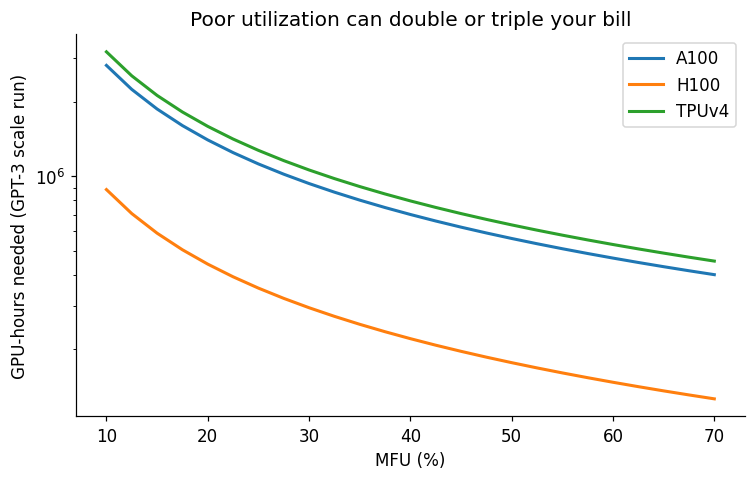

In [5]:
# @title Visualization: how MFU changes the GPU-hours bill { display-mode: "form" }
mfu_range = np.linspace(0.1, 0.7, 25)
gpt3_flops = total_train_flops(175e9, 300e9)

fig, ax = plt.subplots(figsize=(7, 4.5))
for gpu, spec in HARDWARE.items():
    hours = [gpu_hours_needed(gpt3_flops, spec["peak_flops_s"], m) for m in mfu_range]
    ax.plot(mfu_range * 100, hours, label=gpu, lw=2)

ax.set_xlabel("MFU (%)")
ax.set_ylabel("GPU-hours needed (GPT-3 scale run)")
ax.set_yscale("log")
ax.set_title("Poor utilization can double or triple your bill")
ax.legend()
plt.tight_layout()
plt.show()


**The lesson:** halving your MFU roughly *doubles* your GPU-hours bill for the same FLOPs. This is why
infra teams obsess over utilization — it is a lever you control (better parallelism, less communication
overhead) that is just as valuable as buying faster chips.


## Part 3: GPU-hours → \$ cost and energy 🎯

GPU-hours are still not a number you can put in a budget memo. Two more conversions:

- **Dollars**: `using the cost of one hour of GPU usage`
- **Energy**: GPUs draw power even when not at 100% utilization; on top of that, data centers have a
  **Power Usage Effectiveness (PUE)** overhead (cooling, networking, etc.) — typically ~1.1–1.3 for modern
  facilities.


In [6]:
PUE = 1.2  # typical modern data center overhead
GRID_CARBON_INTENSITY_KG_PER_KWH = 0.4  # rough global average, varies hugely by region

def training_cost_usd(gpu_hours: float, price_per_hour: float) -> float:
    '''Total dollar cost of a training run.'''
    # ➔ TODO: one-liner
    return gpu_hours * price_per_hour

def training_energy_kwh(gpu_hours: float, power_watts: float, pue: float = PUE) -> float:
    '''Total energy consumed, in kWh, including data-center overhead (PUE).'''
    # ➔ TODO
    watt_hours = gpu_hours * power_watts * 1000 # Convert hours to seconds for consistent power unit
    kwh = watt_hours / 1000 # Convert Wh to kWh
    return kwh * pue

def training_co2_kg(energy_kwh: float, carbon_intensity: float = GRID_CARBON_INTENSITY_KG_PER_KWH) -> float:
    '''Estimated CO2 emissions in kg.'''
    return energy_kwh * carbon_intensity


for gpu, spec in HARDWARE.items():
    h = gpu_hours_needed(gpt3_flops, spec["peak_flops_s"], spec["mfu"])
    cost = training_cost_usd(h, spec["price_per_hour"])
    energy = training_energy_kwh(h, spec["power_watts"])
    co2 = training_co2_kg(energy)
    print(f"{gpu:6s} | {h:>10,.0f} GPU-h | ${cost:>12,.0f} | {energy:>10,.0f} kWh | {co2:>8,.0f} kg CO2")

A100   |    701,122 GPU-h | $   1,752,804 | 336,538,462 kWh | 134,615,385 kg CO2
H100   |    196,409 GPU-h | $     883,838 | 164,983,165 kWh | 65,993,266 kg CO2
TPUv4  |    636,364 GPU-h | $   2,036,364 | 343,636,364 kWh | 137,454,545 kg CO2


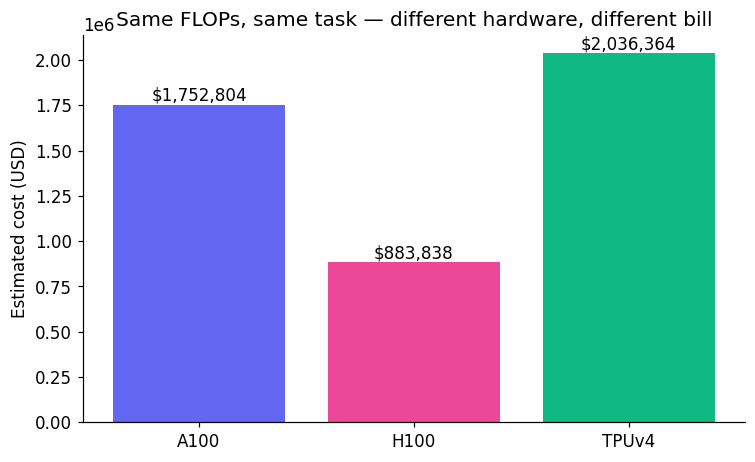

In [7]:
# @title Visualization: cost breakdown by hardware choice { display-mode: "form" }
rows = []
for gpu, spec in HARDWARE.items():
    h = gpu_hours_needed(gpt3_flops, spec["peak_flops_s"], spec["mfu"])
    rows.append({"gpu": gpu, "cost_usd": training_cost_usd(h, spec["price_per_hour"]), "hours": h})
cost_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(cost_df["gpu"], cost_df["cost_usd"], color=["#6366f1", "#ec4899", "#10b981"])
ax.set_ylabel("Estimated cost (USD)")
ax.set_title("Same FLOPs, same task — different hardware, different bill")
for b, v in zip(bars, cost_df["cost_usd"]):
    ax.text(b.get_x() + b.get_width()/2, v, f"${v:,.0f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


**The lesson:** the "fastest" chip is not automatically the cheapest choice — a higher peak-FLOPs GPU
with a higher price tag and lower relative MFU can lose to a cheaper, better-utilized one. Budgeting
means comparing total cost, not sticker price per hour.


## Part 4: the budget dashboard ⚡

Now put it all together. Given *any* model size, we want one function that spits out the full memo: FLOPs,
GPU-hours, cost, energy, CO2 — for a chosen piece of hardware.


In [8]:
def training_budget(n_params: float, n_tokens: float, hardware: str = "H100") -> dict:
    '''Full training budget estimate for a given model size and hardware choice.

    Returns a dict with keys: flops, gpu_hours, cost_usd, energy_kwh, co2_kg
    '''
    spec = HARDWARE[hardware]  # a dict with keys: peak_flops_s, mfu, price_per_hour, power_watts

    # ➔ TODO: chain together the functions you wrote in Parts 1-3
    flops = total_train_flops(n_params, n_tokens)
    gpu_hours = gpu_hours_needed(flops, spec["peak_flops_s"], spec["mfu"])
    cost_usd = training_cost_usd(gpu_hours, spec["price_per_hour"])
    energy_kwh = training_energy_kwh(gpu_hours, spec["power_watts"])
    co2_kg = training_co2_kg(energy_kwh)

    return {
        "flops": flops,
        "gpu_hours": gpu_hours,
        "cost_usd": cost_usd,
        "energy_kwh": energy_kwh,
        "co2_kg": co2_kg,
    }


training_budget(70e9, 1.4e12, hardware="A100")

{'flops': 5.88e+23,
 'gpu_hours': 1308760.6837606838,
 'cost_usd': 3271901.7094017095,
 'energy_kwh': 628205128.2051282,
 'co2_kg': 251282051.2820513}

In [9]:
# @title Interactive: drag the sliders, watch the memo update { display-mode: "form" }
params_slider = widgets.FloatLogSlider(value=7e9, base=10, min=8, max=13, step=0.1, description="Params (N)")
tokens_slider = widgets.FloatLogSlider(value=1e12, base=10, min=9, max=13.5, step=0.1, description="Tokens (D)")
hw_dropdown = widgets.Dropdown(options=list(HARDWARE.keys()), value="H100", description="Hardware")
out = widgets.Output()

def _update(*_):
    with out:
        out.clear_output()
        b = training_budget(params_slider.value, tokens_slider.value, hw_dropdown.value)
        display(HTML(f'''
        <div style="font-family:-apple-system,sans-serif;background:#f8f9fa;color:#212529;border:1px solid #e9ecef;
                     border-radius:12px;padding:16px 20px;max-width:420px">
          <b>FLOPs:</b> {b['flops']:.2e}<br>
          <b>GPU-hours:</b> {b['gpu_hours']:,.0f}<br>
          <b>Cost:</b> ${b['cost_usd']:,.0f}<br>
          <b>Energy:</b> {b['energy_kwh']:,.0f} kWh<br>
          <b>CO2:</b> {b['co2_kg']:,.0f} kg
        </div>
        '''))

for w in (params_slider, tokens_slider, hw_dropdown):
    w.observe(_update, names="value")

display(widgets.VBox([params_slider, tokens_slider, hw_dropdown, out]))
_update()


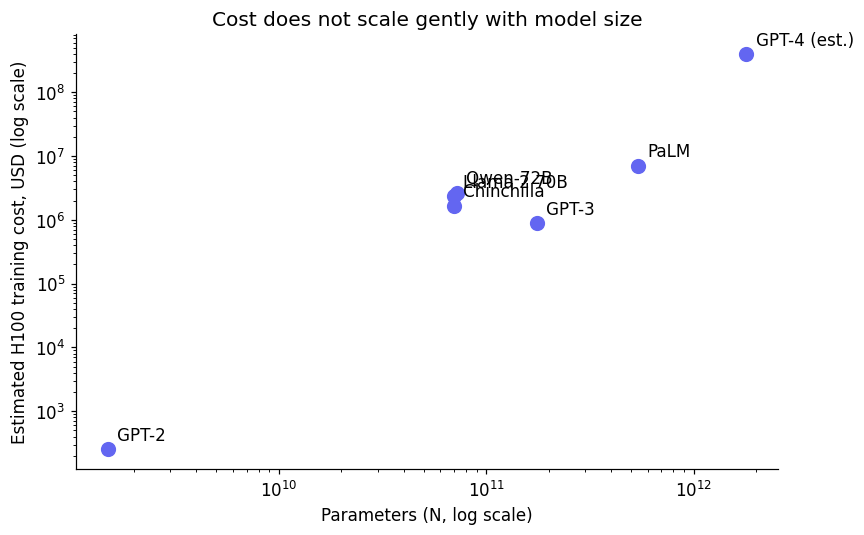

In [14]:
# @title Visualization: cost vs. model scale, benchmarked against real models { display-mode: "form" }
# Approximate public figures (rounded, for teaching purposes only — not audited)
models = pd.DataFrame([
    {"name": "GPT-2",     "params": 1.5e9,   "tokens": 10e9},
    {"name": "GPT-3",     "params": 175e9,   "tokens": 300e9},
    {"name": "Chinchilla","params": 70e9,    "tokens": 1.4e12},
    {"name": "PaLM",      "params": 540e9,   "tokens": 780e9},
    {"name": "Llama 2 70B","params": 70e9,   "tokens": 2.0e12},
    {"name": "GPT-4 (est.)","params": 1.8e12,"tokens": 13e12},
    {"name": "Qwen-72B",  "params": 72e9,    "tokens": 2.2e12}
])
models["flops"] = models.apply(lambda r: total_train_flops(r["params"], r["tokens"]), axis=1)

models["cost_usd"] = models.apply(
    lambda r: training_cost_usd(
        gpu_hours_needed(r["flops"], HARDWARE["H100"]["peak_flops_s"], HARDWARE["H100"]["mfu"]),
        HARDWARE["H100"]["price_per_hour"],
    ),
    axis=1,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(models["params"], models["cost_usd"], s=80, color="#6366f1", zorder=3)
for _, r in models.iterrows():
    ax.annotate(r["name"], (r["params"], r["cost_usd"]), textcoords="offset points", xytext=(6, 6))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Parameters (N, log scale)")
ax.set_ylabel("Estimated H100 training cost, USD (log scale)")
ax.set_title("Cost does not scale gently with model size")
plt.tight_layout()
plt.show()

**The lesson, in one line:** compute cost is not linear in "how big the model feels" — a jump that looks
modest on a parameter count slider can be a 100x jump on your budget memo, because cost scales with
`params × tokens`, not `params` alone. That is the number you now know how to defend in front of your
manager.

Coming up next: once your job is actually running on a cluster, you will want to check whether you are
*getting* the MFU you assumed here — that is exactly what the SLURM session covers.
